# Land-Variable Lead-Time ACC Skill Maps

This notebook computes metrics and plots from analysis-ready inputs produced by `0_run_land_acc_input_preprocessing.ipynb`. It does not open raw model or observational files, perform vertical aggregation, calculate seasonal means, or regrid data.

The staged-input contract is validated before any metric is calculated. This separation keeps raw-data harmonization reproducible and prevents accidental comparisons across mismatched grids, units, seasons, or soil depths.

In [25]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import re
import uuid
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr

from esp_lab import land_skill, stats
from esp_lab.paths import S2D_DIAG_ROOT


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Analysis configuration

These values must identify outputs already created by the `0_run` preprocessing notebook. `REFERENCE_PRODUCT` is the exact product name used there; punctuation is normalized in filenames. The evaluation contract matches `1a_refactor_leadtime_acc_skill_map.ipynb`: 1980–2018 initializations, a nominal 1981–2010 verification-time climatology, ten members, lead-dependent model drift removal, observation anomalies, and linear detrending. Because late leads begin verifying in 1982, their available model climatology contains 29 rather than 30 years; this is validated and recorded explicitly.

In [26]:
field = os.environ.get("ESP_LAB_LAND_FIELD", "H2OSOI").upper()  # H2OSNO, TWS, or H2OSOI
DEFAULT_REFERENCE_PRODUCTS = {"H2OSNO": "C3S_SWE", "H2OSOI": "CPC_Soil_Moisture_V2"}
REFERENCE_PRODUCT = os.environ.get(
    "ESP_LAB_LAND_REFERENCE_PRODUCT",
    DEFAULT_REFERENCE_PRODUCTS.get(field, "CONFIGURE_ME"),
)
SOIL_DEPTH_RANGE_M = (0.0, 1.6) if field == "H2OSOI" else None
GRID_TAG = "1x1deg_cell_centered"

# Match the central evaluation contract in 1a_refactor_leadtime_acc_skill_map.ipynb.
RUN = {
    "initialization_years": (1980, 2018),
    "exclude_year": None,
    "init_months": [5, 11],
    "climatology_years": (1981, 2010),
    "ensemble_members": [f"EN{i:02d}" for i in range(10)],
    "monthly_nlead": 24,
    "seasonal_nlead": 8,
    "detrend": True,
    "strict_member_completeness": True,
    "force_compute": False,
}
EVALUATION_PROTOCOL = "1a_refactor_init1980-2018_clim1981-2010_per-lead_v1"

E3SM_CASES = {
    "E3SM-FOSIRL": {"cache_tag": "JRA55_FOSIRL"},
    "E3SM-Reanalysis": {"cache_tag": "Reanalysis"},
}

PROCESSED_ROOT = Path(
    os.environ.get(
        "ESP_LAB_LAND_ACC_INPUT_ROOT",
        str(Path(S2D_DIAG_ROOT) / "land_acc_inputs"),
    )
)
SKILL_ROOT = Path(S2D_DIAG_ROOT)
# Fixed production figure directory, matching 1a_refactor_leadtime_acc_skill_map.ipynb.
FIGURE_OUTDIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)

if REFERENCE_PRODUCT == "CONFIGURE_ME":
    raise ValueError("Set REFERENCE_PRODUCT to the product staged by the 0_run notebook")

## Resolve and validate staged inputs

In [27]:
def safe_token(value):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value)).strip("_")


def depth_tag():
    if field != "H2OSOI":
        return ""
    top, bottom = SOIL_DEPTH_RANGE_M
    return f"_depth{top:g}-{bottom:g}m_integrated_mm"


PRODUCT_TAG = safe_token(REFERENCE_PRODUCT)


def model_input_path(case_tag, init_month):
    directory = PROCESSED_ROOT / "model" / case_tag / field
    return directory / f"{case_tag}{init_month:02d}_{field}{depth_tag()}_seasonal_{GRID_TAG}.nc"


def reference_input_path():
    directory = PROCESSED_ROOT / "reference" / PRODUCT_TAG / field
    return directory / f"{PRODUCT_TAG}_{field}{depth_tag()}_seasonal_{GRID_TAG}.nc"


def require_contract(da, path, source_kind):
    expected = {
        "processing_stage": "analysis_ready_land_acc_input_v1",
        "field": field,
        "source_kind": source_kind,
        "horizontal_grid": GRID_TAG,
        "seasonal_convention": "centered_3month_DJF_MAM_JJA_SON",
    }
    mismatches = {key: (da.attrs.get(key), value) for key, value in expected.items() if da.attrs.get(key) != value}
    if mismatches:
        raise ValueError(f"Input contract mismatch in {path}: {mismatches}")


def safe_to_netcdf(ds, path):
    path = Path(path)
    temporary = path.with_name(f".{path.name}.tmp.{uuid.uuid4().hex}")
    try:
        ds.to_netcdf(temporary)
        os.replace(temporary, path)
    finally:
        if temporary.exists():
            temporary.unlink()


def validate_skill_cache(skill, init_month, target_years_by_lead):
    expected_leads = list(map(int, target_years_by_lead))
    actual_leads = list(map(int, skill.L.values))
    if actual_leads != expected_leads:
        raise ValueError(f"cached leads {actual_leads} != expected {expected_leads}")
    expected_attrs = {
        "climatology": f"{RUN['climatology_years'][0]}-{RUN['climatology_years'][1]}",
        "detrend": str(bool(RUN['detrend'])).lower(),
        "reference_product": REFERENCE_PRODUCT,
        "evaluation_protocol": EVALUATION_PROTOCOL,
        "initialization_years": f"{RUN['initialization_years'][0]}-{RUN['initialization_years'][1]}",
        "ensemble_members": ",".join(RUN["ensemble_members"]),
        "model_climatology_sample_count_by_lead": ",".join(
            f"{lead}:{sum(RUN['climatology_years'][0] <= year <= RUN['climatology_years'][1] for year in years)}"
            for lead, years in target_years_by_lead.items()
        ),
    }
    mismatches = {
        key: (skill.attrs.get(key), value)
        for key, value in expected_attrs.items()
        if skill.attrs.get(key) != value
    }
    if mismatches:
        raise ValueError(f"cached metadata mismatch: {mismatches}")
    for lead, years in target_years_by_lead.items():
        expected = (len(years), min(years), max(years))
        actual = (
            int(skill.sample_count.sel(L=lead)),
            int(skill.target_year_start.sel(L=lead)),
            int(skill.target_year_end.sel(L=lead)),
        )
        if actual != expected:
            raise ValueError(
                f"cached cohort mismatch for init={init_month}, lead={lead}: "
                f"{actual} != {expected}"
            )


In [28]:
reference_path = reference_input_path()
if not reference_path.exists():
    raise FileNotFoundError(f"Missing staged reference {reference_path}; run 0_run_land_acc_input_preprocessing.ipynb")
reference = xr.open_dataset(reference_path, chunks={"time": -1, "lat": 45, "lon": 90})[field]
require_contract(reference, reference_path, "reference")
reference_is_anomaly = reference.attrs.get("reference_is_anomaly") == "true"

forecast_by_case_month = {}
valid_time_by_case_month = {}
expected_years_by_case_month = {}
for case_name, case_cfg in E3SM_CASES.items():
    forecast_by_case_month[case_name] = {}
    valid_time_by_case_month[case_name] = {}
    expected_years_by_case_month[case_name] = {}
    for init_month in RUN["init_months"]:
        path = model_input_path(case_cfg["cache_tag"], init_month)
        if not path.exists():
            raise FileNotFoundError(f"Missing staged model input {path}; run the 0_run notebook")
        ds = xr.open_dataset(
            path, chunks={"Y": -1, "L": 4, "M": 2, "lat": 45, "lon": 90}
        )
        if "time" not in ds:
            raise ValueError(f"{path} does not contain verification time")
        forecast = ds[field]
        require_contract(forecast, path, "model")
        land_skill.validate_land_reference_compatibility(forecast, reference)
        forecast, valid_time, dropped_leads = land_skill.retain_valid_seasonal_leads(
            forecast, ds.time
        )
        valid_time = valid_time.load()
        expected_years = land_skill.validate_hindcast_evaluation_setup(
            forecast, valid_time, init_month=init_month,
            initialization_years=RUN["initialization_years"],
            expected_members=RUN["ensemble_members"],
            climatology_years=RUN["climatology_years"],
            require_complete_member_grid=RUN["strict_member_completeness"],
        )
        forecast_by_case_month[case_name][init_month] = forecast
        valid_time_by_case_month[case_name][init_month] = valid_time
        expected_years_by_case_month[case_name][init_month] = expected_years
        print("Validated:", case_name, init_month, path, "dropped leads:", dropped_leads)

VALID_LEADS_BY_MONTH = {}
for init_month in RUN["init_months"]:
    lead_coordinates = {
        tuple(forecast_by_case_month[case][init_month].L.values.tolist())
        for case in E3SM_CASES
    }
    if len(lead_coordinates) != 1:
        raise ValueError(
            f"Models do not share valid leads for init={init_month}: {lead_coordinates}"
        )
    VALID_LEADS_BY_MONTH[init_month] = list(next(iter(lead_coordinates)))
print("Valid seasonal leads by initialization month:", VALID_LEADS_BY_MONTH)


Validated: E3SM-FOSIRL 5 /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/land_acc_inputs/model/JRA55_FOSIRL/H2OSOI/JRA55_FOSIRL05_H2OSOI_depth0-1.6m_integrated_mm_seasonal_1x1deg_cell_centered.nc dropped leads: []
Validated: E3SM-FOSIRL 11 /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/land_acc_inputs/model/JRA55_FOSIRL/H2OSOI/JRA55_FOSIRL11_H2OSOI_depth0-1.6m_integrated_mm_seasonal_1x1deg_cell_centered.nc dropped leads: []
Validated: E3SM-Reanalysis 5 /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/land_acc_inputs/model/Reanalysis/H2OSOI/Reanalysis05_H2OSOI_depth0-1.6m_integrated_mm_seasonal_1x1deg_cell_centered.nc dropped leads: []
Validated: E3SM-Reanalysis 11 /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/land_acc_inputs/model/Reanalysis/H2OSOI/Reanalysis11_H2OSOI_depth0-1.6m_integrated_mm_seasonal_1x1deg_cell_centered.nc dropped leads: []
Common valid seasonal leads: [3, 6, 9, 12, 15, 18, 21]


## Establish common target-year cohorts

For each initialization month and lead, all E3SM cases use the same intersection of model and reference target years. This prevents apparent skill differences caused only by unequal temporal samples.

In [29]:
common_years_by_month = {}
model_climatology_count_by_month = {}
for init_month in RUN["init_months"]:
    model_fields = {
        case_name: forecast_by_case_month[case_name][init_month]
        for case_name in E3SM_CASES
    }
    model_times = {
        case_name: valid_time_by_case_month[case_name][init_month]
        for case_name in E3SM_CASES
    }
    leads = VALID_LEADS_BY_MONTH[init_month][: RUN["seasonal_nlead"]]
    expected_cohorts = {
        case_name: {int(lead): expected_years_by_case_month[case_name][init_month][int(lead)] for lead in leads}
        for case_name in E3SM_CASES
    }
    first_expected = expected_cohorts[next(iter(expected_cohorts))]
    if any(cohort != first_expected for cohort in expected_cohorts.values()):
        raise ValueError(f"Cases have different configured target years for init={init_month}")
    land_skill.validate_reference_time_coverage(
        reference, first_expected, model_times[next(iter(model_times))],
        RUN["climatology_years"],
    )
    common_years = stats.common_valid_target_years_seasonal(
        model_fields, model_times, reference, leads, require_all_members=True
    )
    if common_years != first_expected:
        raise ValueError(
            f"Evaluation cohort is incomplete for init={init_month}: "
            f"expected={first_expected}, common={common_years}"
        )
    common_years_by_month[init_month] = common_years
    climy0, climy1 = RUN["climatology_years"]
    model_climatology_count_by_month[init_month] = {
        lead: sum(climy0 <= year <= climy1 for year in years)
        for lead, years in common_years.items()
    }
    print(init_month, {lead: (min(years), max(years), len(years)) for lead, years in common_years.items()})
    print("model climatology N by lead:", model_climatology_count_by_month[init_month])

5 {3: (1980, 2018, 39), 6: (1980, 2018, 39), 9: (1981, 2019, 39), 12: (1981, 2019, 39), 15: (1981, 2019, 39), 18: (1981, 2019, 39), 21: (1982, 2020, 39)}
model climatology N by lead: {3: 30, 6: 30, 9: 30, 12: 30, 15: 30, 18: 30, 21: 29}
11 {3: (1981, 2019, 39), 6: (1981, 2019, 39), 9: (1981, 2019, 39), 12: (1981, 2019, 39), 15: (1982, 2020, 39), 18: (1982, 2020, 39), 21: (1982, 2020, 39)}
model climatology N by lead: {3: 30, 6: 30, 9: 30, 12: 30, 15: 29, 18: 29, 21: 29}


## Compute and cache ACC metrics

In [30]:
climy0, climy1 = RUN["climatology_years"]
trend_tag = "detrend" if RUN["detrend"] else "nodetrend"
skill_by_case_month = {}

for case_name, case_cfg in E3SM_CASES.items():
    skill_by_case_month[case_name] = {}
    outdir = SKILL_ROOT / case_cfg["cache_tag"] / "leadtime_acc" / "skill" / "land" / field
    outdir.mkdir(parents=True, exist_ok=True)
    for init_month in RUN["init_months"]:
        filename = (
            f"{case_cfg['cache_tag']}{init_month:02d}_{field}{depth_tag()}_"
            f"{PRODUCT_TAG}_skill_clim_{climy0}_{climy1}_{trend_tag}.nc"
        )
        outfile = outdir / filename
        use_cache = False
        if outfile.exists() and not RUN["force_compute"]:
            cached = xr.open_dataset(outfile).load()
            try:
                validate_skill_cache(cached, init_month, common_years_by_month[init_month])
                if "valid_sample_count" not in cached:
                    raise ValueError("cache predates grid-cell sample-count tracking")
            except (KeyError, ValueError) as exc:
                print(f"Recomputing incompatible cache {outfile}: {exc}")
            else:
                skill = cached
                use_cache = True
        if not use_cache:
            skill = land_skill.compute_land_acc_skill(
                forecast_by_case_month[case_name][init_month],
                valid_time_by_case_month[case_name][init_month],
                reference, climy0, climy1,
                nleads=min(RUN["seasonal_nlead"], len(common_years_by_month[init_month])),
                reference_is_anomaly=reference_is_anomaly,
                target_years_by_lead=common_years_by_month[init_month],
            ).compute()
            skill.attrs.update({
                "reference_product": REFERENCE_PRODUCT,
                "sample_alignment": "complete configured target years shared across E3SM cases and reference by lead",
                "evaluation_protocol": EVALUATION_PROTOCOL,
                "initialization_years": f"{RUN['initialization_years'][0]}-{RUN['initialization_years'][1]}",
                "ensemble_members": ",".join(RUN["ensemble_members"]),
                "model_climatology_sample_count_by_lead": ",".join(
                    f"{lead}:{count}"
                    for lead, count in model_climatology_count_by_month[init_month].items()
                ),
                "pointwise_significance": "effective-correlation p-value; no spatial multiple-testing correction",
            })
            safe_to_netcdf(skill, outfile)
        validate_skill_cache(skill, init_month, common_years_by_month[init_month])
        skill_by_case_month[case_name][init_month] = skill
        print(outfile, dict(skill.sizes), "N=", skill.sample_count.values.tolist())

/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/skill/land/H2OSOI/JRA55_FOSIRL05_H2OSOI_depth0-1.6m_integrated_mm_CPC_Soil_Moisture_V2_skill_clim_1981_2010_detrend.nc {'L': 7, 'lat': 180, 'lon': 360} N= [39, 39, 39, 39, 39, 39, 39]
/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/skill/land/H2OSOI/JRA55_FOSIRL11_H2OSOI_depth0-1.6m_integrated_mm_CPC_Soil_Moisture_V2_skill_clim_1981_2010_detrend.nc {'L': 7, 'lat': 180, 'lon': 360} N= [39, 39, 39, 39, 39, 39, 39]
/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/leadtime_acc/skill/land/H2OSOI/Reanalysis05_H2OSOI_depth0-1.6m_integrated_mm_CPC_Soil_Moisture_V2_skill_clim_1981_2010_detrend.nc {'L': 7, 'lat': 180, 'lon': 360} N= [39, 39, 39, 39, 39, 39, 39]
/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/leadtime_acc/skill/land/H2OSOI/Reanalysis11_H2OSOI_depth0-1.6m_integrated_mm_CPC_Soil_Moisture_V2_skill_clim_1981_2010_detrend.nc {'L': 7, 'lat': 180, 'lon': 360} N= [39, 39, 39, 39, 39, 39, 39]


## Combined significance-masked ACC figure

This follows the multi-panel style of `1a_refactor_leadtime_acc_skill_map.ipynb`: rows are valid seasonal leads, columns are E3SM cases grouped under May and November initialization headers, and only the outer axes carry latitude/longitude labels.

Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_h2osoi_depth0-1.6m_integrated_mm_CPC_Soil_Moisture_V2_multi_e3sm_acc_sigmask_p10.png


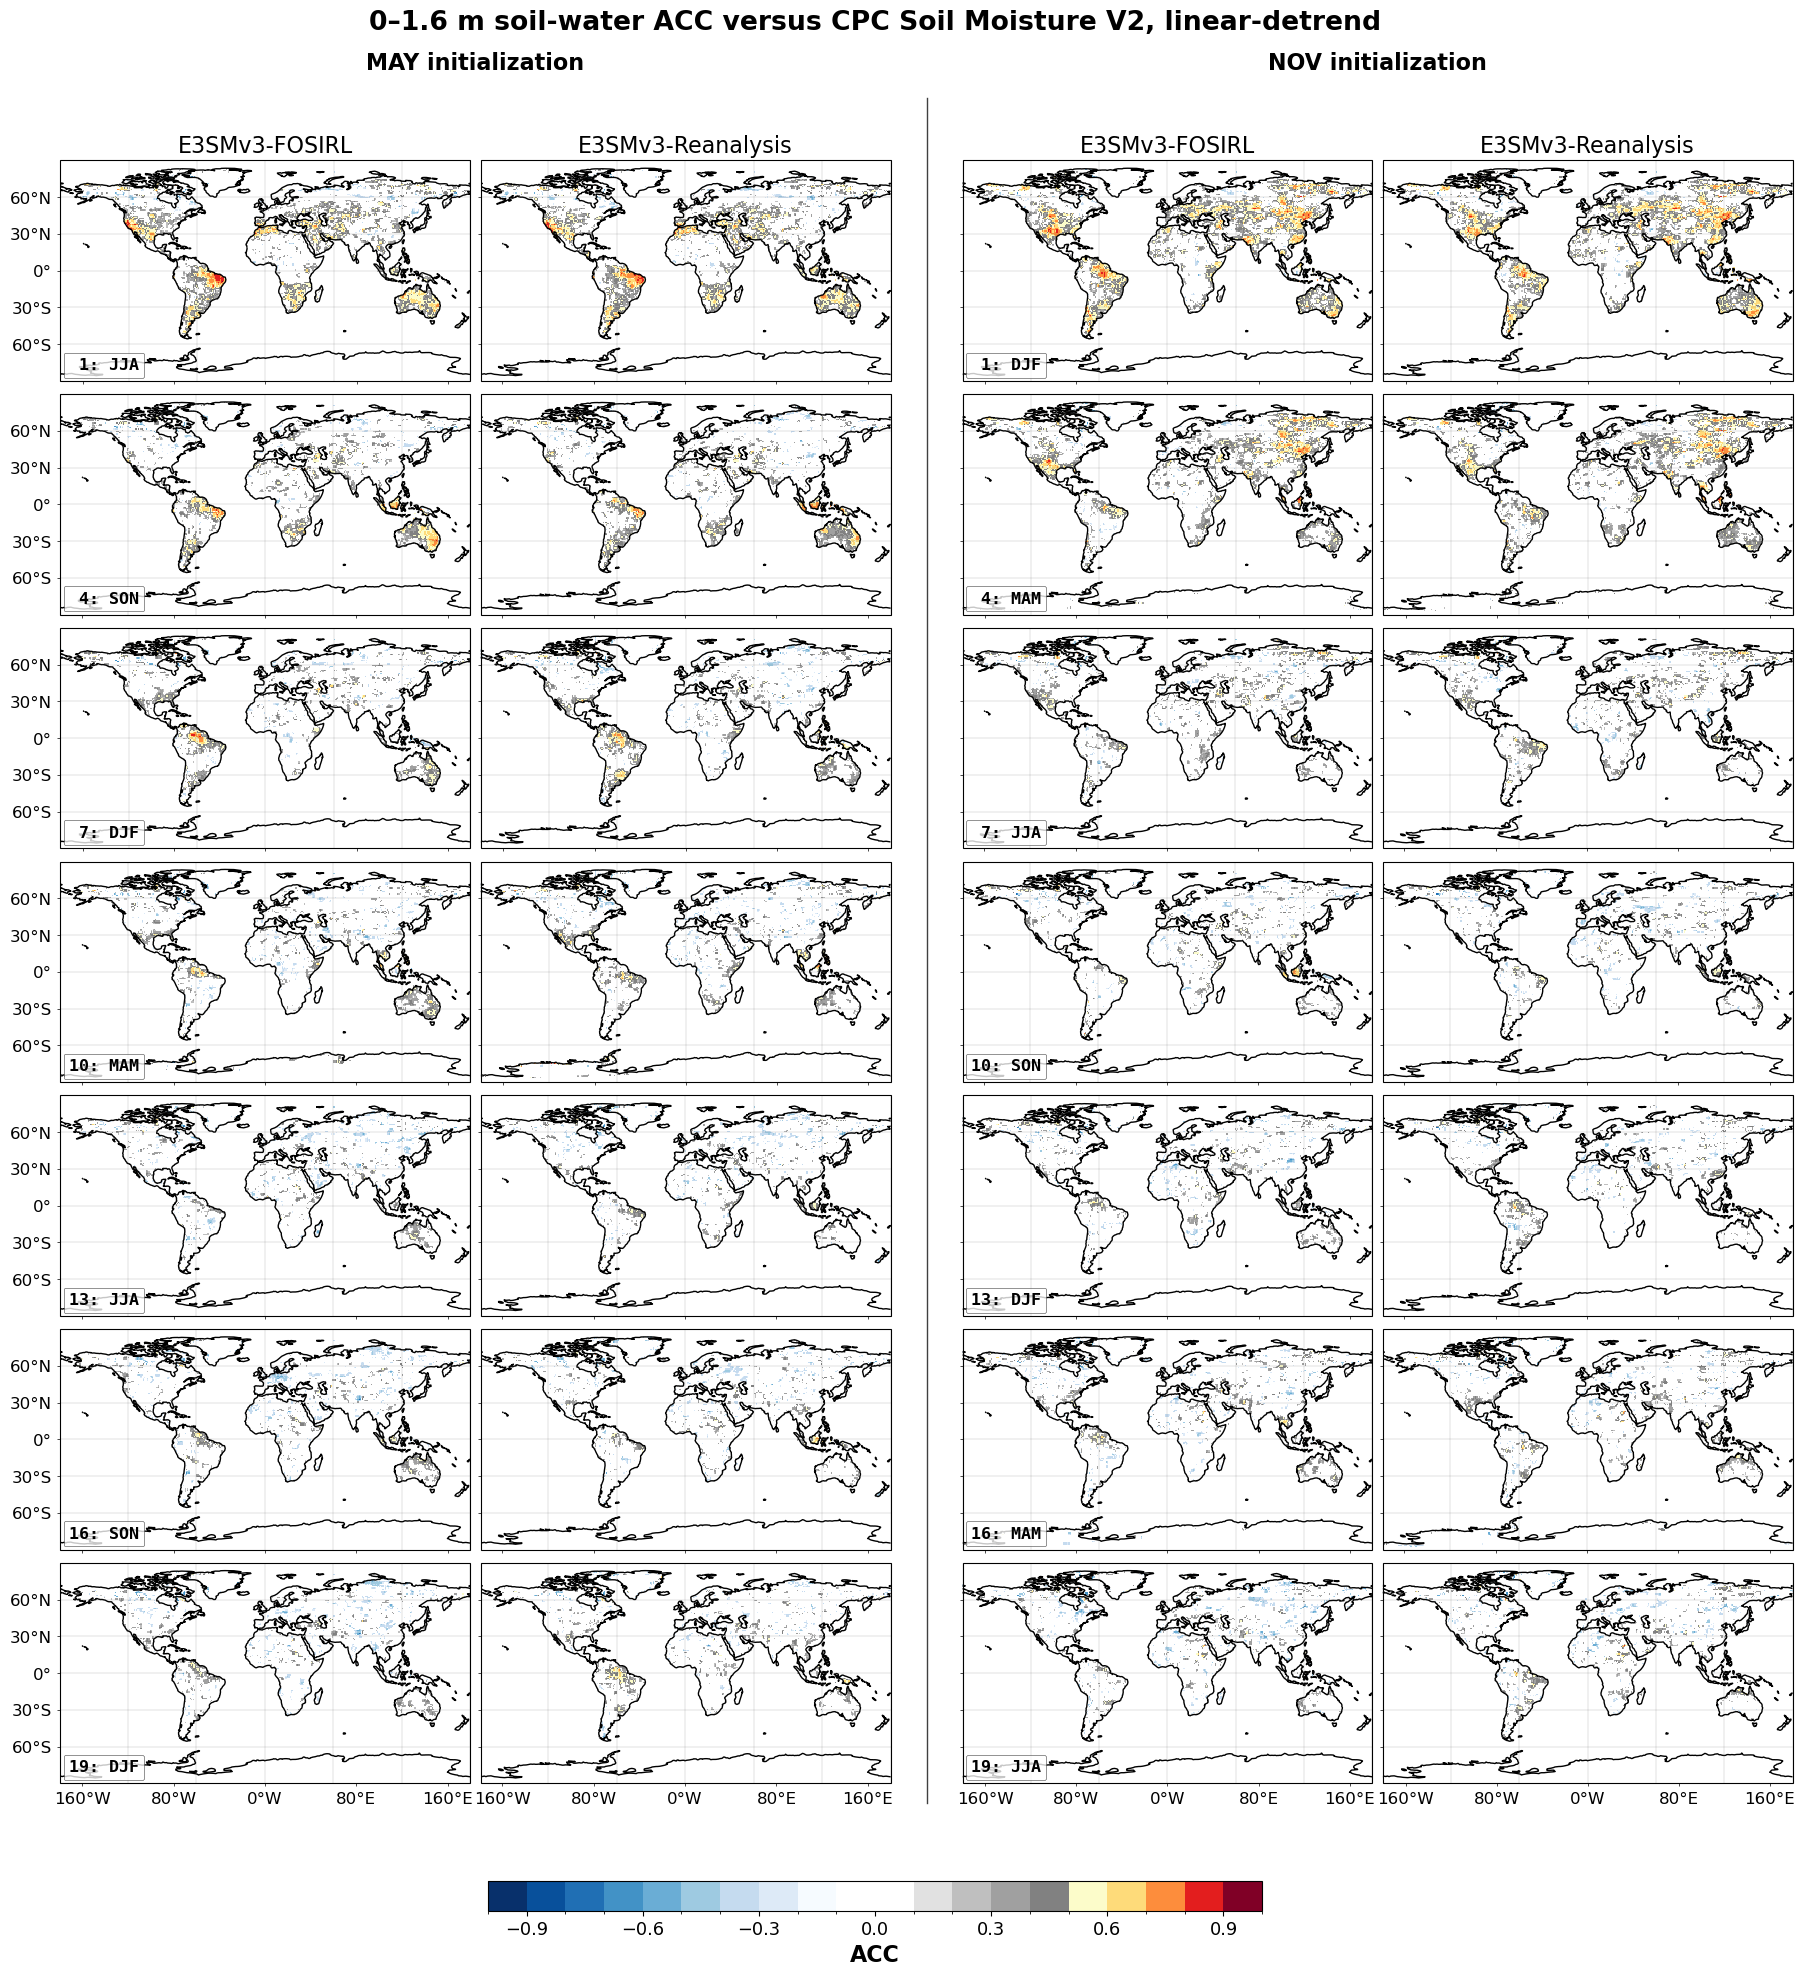

In [31]:
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from matplotlib.offsetbox import AnchoredText

from esp_lab.utils import mapplot_utils as maps
from esp_lab.utils import mov_utils as mov

spec = land_skill.get_land_variable_spec(field)
REFERENCE_DISPLAY_NAME = REFERENCE_PRODUCT.replace("_", " " )
VARIABLE_DISPLAY_NAME = (
    "0–1.6 m soil-water" if field == "H2OSOI" else spec.plot_name
)
PLOT = {
    "significance_mask": True,
    "significance_level": 0.1,
    "mask_negative_acc": False,
    "cmap": "blue2red_acc",
    "color_interval": 0.1,
    "color_min": -1.0,
    "color_max": 1.0,
    "color_cutoff": 0.5,
    "font_size": 16,
    "column_width": 4.4,
    "row_height": 2.8,
    "section_gap": 0.035,
    "dpi": 300,
}

init_month_names = {5: "MAY", 11: "NOV"}
case_display_names = {
    "E3SM-FOSIRL": "E3SMv3-FOSIRL",
    "E3SM-Reanalysis": "E3SMv3-Reanalysis",
}


def season_name(init_month, lead):
    center_month = ((init_month + int(lead) - 2) % 12) + 1
    if center_month in (12, 1, 2):
        return "DJF"
    if center_month in (3, 4, 5):
        return "MAM"
    if center_month in (6, 7, 8):
        return "JJA"
    return "SON"


def style_map_axis(ax, row, col, nrows):
    ax.set_xticks([-160, -80, 0, 80, 160], crs=ccrs.PlateCarree())
    ax.set_yticks([-60, -30, 0, 30, 60], crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(
        LongitudeFormatter(zero_direction_label=True) if row == nrows - 1
        else plt.NullFormatter()
    )
    ax.yaxis.set_major_formatter(LatitudeFormatter() if col == 0 else plt.NullFormatter())
    ax.tick_params(
        labelsize=PLOT["font_size"] * 0.75, length=2.5, width=0.5,
        top=False, right=False, labelbottom=(row == nrows - 1), labelleft=(col == 0),
    )
    ax.gridlines(
        crs=ccrs.PlateCarree(), linewidth=0.35, color="0.35",
        alpha=0.35, linestyle="-", draw_labels=False,
    )


def add_lead_badge(ax, init_month, lead):
    display_lead = int(lead) - 2
    badge = AnchoredText(
        f"{display_lead:2d}: {season_name(init_month, lead)}",
        loc="lower left",
        prop={"size": PLOT["font_size"] * 0.75, "weight": "bold", "family": "monospace"},
        frameon=True, pad=0.2, borderpad=0.3,
    )
    badge.patch.set(
        facecolor=(1, 1, 1, 0.78), edgecolor="0.25",
        linewidth=0.4, boxstyle="round,pad=0.1",
    )
    ax.add_artist(badge)


def add_missing_reference_panel(fig, nrows, ncols, subplot, title):
    ax = fig.add_subplot(nrows, ncols, subplot, projection=ccrs.PlateCarree())
    ax.set_global()
    ax.coastlines(linewidth=0.6, color="0.45")
    ax.set_facecolor("0.94")
    ax.set_title(title, fontsize=PLOT["font_size"], fontweight="bold")
    ax.text(
        0.5, 0.5, "No C3S SWE\nobservations", transform=ax.transAxes,
        ha="center", va="center", fontsize=PLOT["font_size"] * 0.8,
        color="0.35", fontweight="bold",
    )
    return ax


column_specs = [
    (init_month, case_name)
    for init_month in RUN["init_months"]
    for case_name in E3SM_CASES
    if init_month in skill_by_case_month.get(case_name, {})
]
FULL_SEASONAL_LEADS = list(range(3, RUN["monthly_nlead"], 3))[
    : RUN["seasonal_nlead"]
]
plot_leads_by_month = {
    month: FULL_SEASONAL_LEADS for month in RUN["init_months"]
}
if not column_specs or not any(plot_leads_by_month.values()):
    raise RuntimeError("No common case/month/lead combinations are available for plotting")

corr_by_case_month = {}
for init_month, case_name in column_specs:
    skill = skill_by_case_month[case_name][init_month]
    corr = skill.corr.where(skill.valid_sample_count == skill.sample_count)
    if PLOT["significance_mask"]:
        corr = corr.where(skill.pval < PLOT["significance_level"])
    if PLOT["mask_negative_acc"]:
        corr = corr.where(corr >= 0)
    corr_by_case_month[(init_month, case_name)] = corr

nrows = max(map(len, plot_leads_by_month.values()))
ncols = len(column_specs)
projection = ccrs.PlateCarree()
fig = plt.figure(
    figsize=(PLOT["column_width"] * ncols, PLOT["row_height"] * nrows)
)
mappable = None

for row in range(nrows):
    for col, (init_month, case_name) in enumerate(column_specs):
        month_leads = plot_leads_by_month[init_month]
        subplot = row * ncols + col + 1
        lead = month_leads[row]
        skill = skill_by_case_month[case_name][init_month]
        title = case_display_names.get(case_name, case_name) if row == 0 else ""
        if lead in skill.L.values:
            ax, mappable = maps.map_pcolor_global_subplot(
                fig, corr_by_case_month[(init_month, case_name)].sel(L=lead),
                skill.lon, skill.lat,
                PLOT["color_interval"], PLOT["color_min"], PLOT["color_max"],
                title, nrows, ncols, subplot, projection,
                cmap=PLOT["cmap"], cutoff=PLOT["color_cutoff"],
                fontsize=PLOT["font_size"],
            )
        else:
            ax = add_missing_reference_panel(fig, nrows, ncols, subplot, title)
        style_map_axis(ax, row, col, nrows)
        if col == 0 or (col > 0 and column_specs[col - 1][0] != init_month):
            add_lead_badge(ax, init_month, lead)

fig.suptitle(
    f"{VARIABLE_DISPLAY_NAME} ACC versus {REFERENCE_DISPLAY_NAME}, "
    f"{'linear-detrend' if RUN['detrend'] else 'no-detrend'}",
    fontsize=PLOT["font_size"] * 1.2, fontweight="bold", y=0.995,
)
layout_top = 0.90 if nrows <= 4 else 0.96
section_header_y = 0.925 if nrows <= 4 else 0.962
divider_top = 0.915 if nrows <= 4 else 0.95
fig.tight_layout(rect=[0.0, 0.075, 1.0, layout_top])
fig.subplots_adjust(bottom=0.09, hspace=0.06, wspace=0.025)

# Add a small gap and divider between initialization-month groups.
second_month = RUN["init_months"][1] if len(RUN["init_months"]) > 1 else None
if second_month is not None:
    second_cols = [i for i, (month, _) in enumerate(column_specs) if month == second_month]
    for row in range(nrows):
        for col in second_cols:
            ax = fig.axes[row * ncols + col]
            pos = ax.get_position()
            ax.set_position([pos.x0 + PLOT["section_gap"], pos.y0, pos.width, pos.height])

for init_month in RUN["init_months"]:
    cols = [i for i, (month, _) in enumerate(column_specs) if month == init_month]
    if cols:
        left = min(fig.axes[col].get_position().x0 for col in cols)
        right = max(fig.axes[col].get_position().x1 for col in cols)
        fig.text(
            (left + right) / 2, section_header_y, f"{init_month_names.get(init_month, init_month)} initialization",
            ha="center", va="bottom", fontsize=PLOT["font_size"], fontweight="bold",
        )

if second_month is not None:
    first_cols = [i for i, (month, _) in enumerate(column_specs) if month != second_month]
    second_cols = [i for i, (month, _) in enumerate(column_specs) if month == second_month]
    divider_x = (
        max(fig.axes[col].get_position().x1 for col in first_cols)
        + min(fig.axes[col].get_position().x0 for col in second_cols)
    ) / 2
    fig.add_artist(plt.Line2D(
        [divider_x, divider_x], [0.08, divider_top], transform=fig.transFigure,
        color="0.25", linewidth=1.0,
    ))

colorbar_ax = fig.add_axes([0.28, 0.025, 0.44, 0.015])
colorbar = fig.colorbar(mappable, cax=colorbar_ax, orientation="horizontal")
colorbar.set_label("ACC", fontsize=PLOT["font_size"], fontweight="bold")
colorbar.ax.tick_params(labelsize=PLOT["font_size"] * 0.8)

mask_tag = "sigmask_p10" if PLOT["significance_mask"] else "no_sigmask"
figure_name = (
    f"fig_{field.lower()}{depth_tag()}_{PRODUCT_TAG}_multi_e3sm_acc_{mask_tag}.png"
)
figure_path = FIGURE_OUTDIR / figure_name
mov.save_figure(
    fig, figure_path, mode="", metric="leadtime_acc",
    title=f"Lead-time ACC Skill: {field} versus {REFERENCE_PRODUCT}",
    caption="ACC rows by seasonal lead using complete configured cohorts; pointwise effective-correlation p < 0.1 without spatial multiple-testing correction.",
    dpi=PLOT["dpi"],
)
print("Saved figure:", figure_path)
plt.show()

## FOSIRL minus Reanalysis ACC difference

This descriptive comparison uses the same lead-by-initialization layout. Positive values indicate higher ACC for E3SMv3-FOSIRL; no difference-significance stippling is shown because the cached skill files do not contain paired resampling statistics for the ACC difference.

Saved difference figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_h2osoi_depth0-1.6m_integrated_mm_CPC_Soil_Moisture_V2_fosirl_minus_reanalysis_acc.png


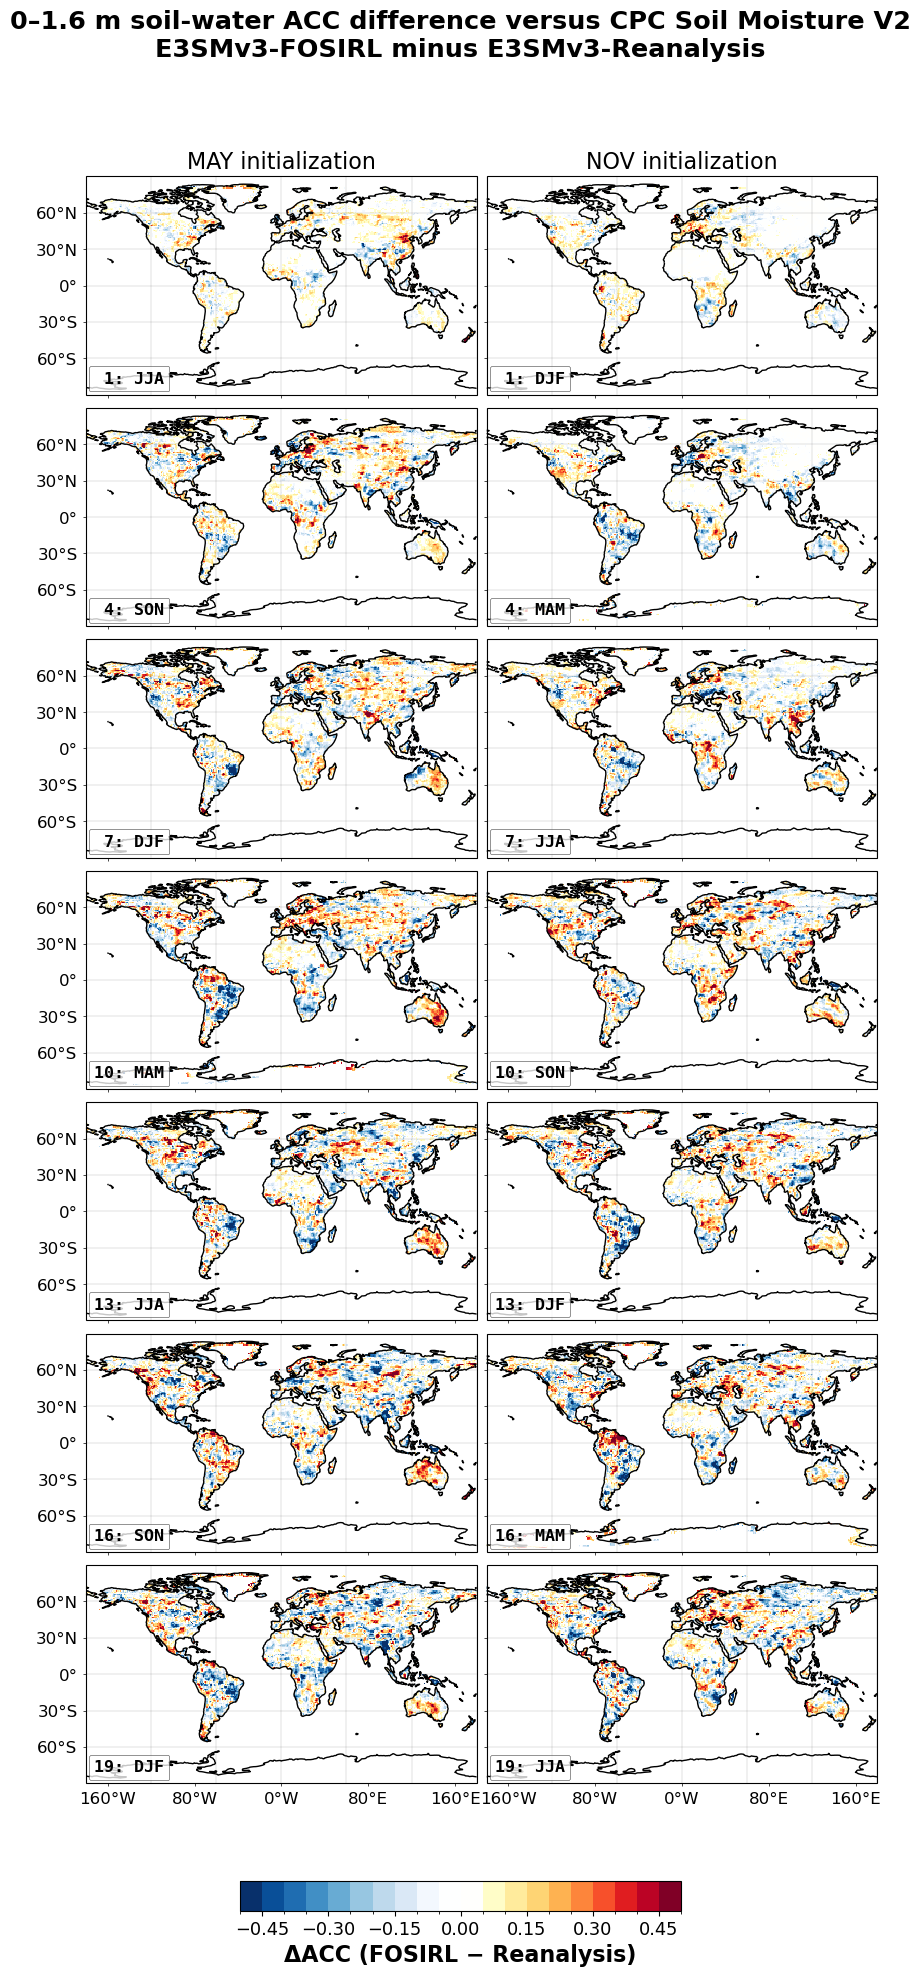

In [32]:
DIFF_PLOT = {
    "color_interval": 0.05,
    "color_min": -0.5,
    "color_max": 0.5,
    "color_cutoff": 0.25,
    "cmap": "blue2red",
}
comparison_cases = ("E3SM-FOSIRL", "E3SM-Reanalysis")
missing_cases = [case for case in comparison_cases if case not in skill_by_case_month]
if missing_cases:
    raise RuntimeError(f"Missing comparison cases: {missing_cases}")

difference_months = [
    month for month in RUN["init_months"]
    if all(month in skill_by_case_month[case] for case in comparison_cases)
]
difference_leads_by_month = {
    month: FULL_SEASONAL_LEADS for month in difference_months
}
if not difference_months or not any(difference_leads_by_month.values()):
    raise RuntimeError("No common month/lead combinations are available for the ACC difference")

acc_difference = {}
for init_month in difference_months:
    fosirl_skill = skill_by_case_month[comparison_cases[0]][init_month]
    reanalysis_skill = skill_by_case_month[comparison_cases[1]][init_month]
    fosirl = fosirl_skill.corr.where(
        fosirl_skill.valid_sample_count == fosirl_skill.sample_count
    )
    reanalysis = reanalysis_skill.corr.where(
        reanalysis_skill.valid_sample_count == reanalysis_skill.sample_count
    )
    acc_difference[init_month] = fosirl - reanalysis

nrows = max(map(len, difference_leads_by_month.values()))
ncols = len(difference_months)
fig = plt.figure(figsize=(PLOT["column_width"] * ncols, PLOT["row_height"] * nrows))
mappable = None
for row in range(nrows):
    for col, init_month in enumerate(difference_months):
        month_leads = difference_leads_by_month[init_month]
        subplot = row * ncols + col + 1
        lead = month_leads[row]
        skill = skill_by_case_month[comparison_cases[0]][init_month]
        title = (
            f"{init_month_names.get(init_month, init_month)} initialization"
            if row == 0 else ""
        )
        if lead in acc_difference[init_month].L.values:
            ax, mappable = maps.map_pcolor_global_subplot(
                fig, acc_difference[init_month].sel(L=lead), skill.lon, skill.lat,
                DIFF_PLOT["color_interval"], DIFF_PLOT["color_min"], DIFF_PLOT["color_max"],
                title, nrows, ncols, subplot, projection,
                cmap=DIFF_PLOT["cmap"], cutoff=DIFF_PLOT["color_cutoff"],
                fontsize=PLOT["font_size"],
            )
        else:
            ax = add_missing_reference_panel(fig, nrows, ncols, subplot, title)
        style_map_axis(ax, row, col, nrows)
        add_lead_badge(ax, init_month, lead)

fig.suptitle(
    f"{VARIABLE_DISPLAY_NAME} ACC difference versus {REFERENCE_DISPLAY_NAME}\n"
    "E3SMv3-FOSIRL minus E3SMv3-Reanalysis",
    fontsize=PLOT["font_size"] * 1.15, fontweight="bold", y=0.995,
)
fig.tight_layout(rect=[0.0, 0.075, 1.0, 0.965])
fig.subplots_adjust(bottom=0.09, hspace=0.06, wspace=0.025)
colorbar_ax = fig.add_axes([0.25, 0.025, 0.50, 0.015])
colorbar = fig.colorbar(mappable, cax=colorbar_ax, orientation="horizontal")
colorbar.set_label("ΔACC (FOSIRL − Reanalysis)", fontsize=PLOT["font_size"], fontweight="bold")
colorbar.ax.tick_params(labelsize=PLOT["font_size"] * 0.8)

difference_name = (
    f"fig_{field.lower()}{depth_tag()}_{PRODUCT_TAG}_fosirl_minus_reanalysis_acc.png"
)
difference_path = FIGURE_OUTDIR / difference_name
mov.save_figure(
    fig, difference_path, mode="", metric="leadtime_acc_difference",
    title=f"Lead-time ACC Difference: {field} versus {REFERENCE_DISPLAY_NAME}",
    caption="FOSIRL minus Reanalysis ACC by seasonal lead and initialization month.",
    dpi=PLOT["dpi"],
)
print("Saved difference figure:", difference_path)
plt.show()